In [2]:
# Pipeline to slice catalogue into volume limited redshift slices and compare LF estimates


import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits
#
# Specify regions to loop over
regions=('S','N')
#
# Read the enhanced BGS catalogue produced by Augment_BGS_cat.ipynb and write LF estimates to named file
catalogue='sdata/BGS_Y3_Sept2025_photounbiased_z0p05to0p1.fits'
LF_FILE='LF_Y3_Sept2025_photounbiased_z0p05to0p1.fits'
dat=Table.read(catalogue)
print('Meta data stored with ths table:')
print(dat.meta)
#
# Check selection cuts agree with stored meta data of the sample we have read
Sel=ca.selection('S')
assert dat.meta['FAINT_S'] == Sel['faint'], f"Faint limits do not match: {dat.meta['FAINT_S']} != {Sel['faint']}"
assert dat.meta['BRIGHT_S'] == Sel['bright'], f"Bright limits do not match: {dat.meta['BRIGHT_S']} != {Sel['bright']}"
assert dat.meta['ZMAX_S'] == Sel['zmax'], f"Zmax do not match: {dat.meta['ZMAX_S']} != {Sel['zmax']}"
assert dat.meta['ZMIN_S'] == Sel['zmin'], f"Zmin do not match: {dat.meta['ZMIN_S']} != {Sel['zmin']}"
assert dat.meta['QEVOL_S'] == Sel['Qevol'], f"Qevol do not match: {dat.meta['QEVOL_S']} != {Sel['Qevol']}"
assert dat.meta['AREA_S'] == Sel['area'], f"Areas do not match: {dat.meta['AREA_S']} != {Sel['area']}"
assert dat.meta['F_RAN_S'] == Sel['f_ran'], f"f_ran do not match: {dat.meta['F_RAN_S']} != {Sel['f_ran']}"
assert dat.meta['COL_S'] == Sel['col'], f"Colours do not match: {dat.meta['COL_S']} != {Sel['col']}"
assert dat.meta['STYLE_S'] == Sel['style'], f"Styles do not match: {dat.meta['STYLE_S']} != {Sel['style']}"
Sel=ca.selection('N')
assert dat.meta['FAINT_N'] == Sel['faint'], f"Faint limits do not match: {dat.meta['FAINT_N']} != {Sel['faint']}"
assert dat.meta['BRIGHT_N'] == Sel['bright'], f"Bright limits do not match: {dat.meta['BRIGHT_N']} != {Sel['bright']}"
assert dat.meta['ZMAX_N'] == Sel['zmax'], f"Zmax do not match: {dat.meta['ZMAX_N']} != {Sel['zmax']}"
assert dat.meta['ZMIN_N'] == Sel['zmin'], f"Zmin do not match: {dat.meta['ZMIN_N']} != {Sel['zmin']}"
assert dat.meta['QEVOL_N'] == Sel['Qevol'], f"Qevol do not match: {dat.meta['QEVOL_N']} != {Sel['Qevol']}"
assert dat.meta['AREA_N'] == Sel['area'], f"Areas do not match: {dat.meta['AREA_N']} != {Sel['area']}"
assert dat.meta['F_RAN_N'] == Sel['f_ran'], f"f_ran do not match: {dat.meta['F_RAN_N']} != {Sel['f_ran']}"
assert dat.meta['COL_N'] == Sel['col'], f"Colours do not match: {dat.meta['COL_N']} != {Sel['col']}"
assert dat.meta['STYLE_N'] == Sel['style'], f"Styles do not match: {dat.meta['STYLE_N']} != {Sel['style']}"

# Check cosmology used matches with that used to create the catalogue
assert dat.meta['OM0'] == ca.cosmo.Om0, f"Omega_0 does not match: {dat.meta['OM0']} != {ca.cosmo.Om0}"
assert dat.meta['H0'] == ca.cosmo.H0.value, f"H_0 does not match: {dat.meta['H0']} != {ca.cosmo.H0.value}"
assert dat.meta['TCMB0'] == ca.cosmo.Tcmb0.value, f"Omega_0 does not match: {dat.meta['OM0']} != {ca.cosmo.Tcmb0.value}"



if 'izbin' in dat.colnames:
    print('Will replace existing izbin, invollim, vollim and compl columns')
else:
    #Placeholders for additional columns to add to the table 
    dat.add_column(Column(name='izbin', dtype='int', data=np.zeros(dat['Z'].size))) # redshift bin label 
    dat.add_column(Column(name='invollim', format='L',data=np.zeros(dat['Z'].size,dtype='bool'))) # flag if in the volume limited subset of this redshift bin 
    dat.add_column(Column(name='vollim', data=np.zeros(dat['Z'].size))) # volume of redshift slice it is in
    dat.add_column(Column(name='compl', format='L', data=np.zeros(dat['Z'].size),dtype='bool')) # flag if within colour complete sample

print('Statistics of the data in the table:')
dat.info('stats')

 

Meta data stored with ths table:
OrderedDict([('EXTNAME', 'LSS'), ('QEVOL_N', 0.78), ('ZMAX_N', 0.1), ('ZMIN_N', 0.05), ('BRIGHT_N', 10.0), ('FAINT_N', 19.54), ('AREA_N', 0.09278121822233744), ('F_RAN_N', 1.0), ('COL_N', 'blue'), ('STYLE_N', 'dashed'), ('QEVOL_S', 0.78), ('ZMAX_S', 0.1), ('ZMIN_S', 0.05), ('BRIGHT_S', 10.0), ('FAINT_S', 19.5), ('AREA_S', 0.2067143725378028), ('F_RAN_S', 1.0), ('COL_S', 'red'), ('STYLE_S', 'solid'), ('H0', 100.0), ('TCMB0', 2.725), ('OM0', 0.313), ('PMATCH', True)])
Statistics of the data in the table:
<Table length=856973>
       name            mean        std         min          max    
------------------ ----------- ----------- ------------ -----------
          TARGETID 3.96295e+16 2.43639e+12  3.96273e+16 3.96373e+16
                 Z   0.0773689   0.0136609    0.0500004   0.0999999
             NTILE     2.42652    0.909649            1           5
                RA     185.914     91.4152   0.00063123     359.999
               DEC     20.739

In [3]:
# Read one the corresponding Y3 random (It is matched to the orginal clustering catalogue and not yet the cuts made to our sample
fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_7_clustering.ran.fits'
ranfull=ca.Y3load_catalogues(fpath)


print('Full Random Catalogue statistics:')
ranfull.info('stats')


#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (ranfull['Z'] > Sel['zmin']) & (ranfull['Z'] < Sel['zmax']) & (np.random.rand(ranfull['Z'].size)<Sel['f_ran'])\
      & (ranfull['rmag'] < Sel['faint'])  & (ranfull['rmag'] > Sel['bright']) & (ranfull['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (ranfull['Z'] > Sel['zmin']) & (ranfull['Z'] < Sel['zmax']) &(np.random.rand(ranfull['Z'].size)<Sel['f_ran']) \
      & (ranfull['rmag'] < Sel['faint'])  & (ranfull['rmag'] > Sel['bright']) & (ranfull['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
ran=ranfull[smask]    
print('Statistics after applying sample selection cuts:')
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())
ran.info('stats')


Full Random Catalogue statistics:
<Table length=30890761>
      name           mean        std         min         max    
---------------- ----------- ----------- ----------- -----------
        TARGETID  3.2786e+17 2.48765e+12 3.27858e+17 3.27868e+17
              RA     182.362     93.1026 1.44426e-05         360
             DEC     22.0439     23.2156    -19.5674     79.2522
           NTILE     2.24559    0.944439           1           5
         PHOTSYS          --          --          --          --
FRAC_TLOBS_TILES    0.977861   0.0316573           0           1
               Z    0.213384    0.104274  0.00200098     0.59999
          WEIGHT     1.26497    0.755124           0     68.9124
      WEIGHT_SYS           1           0           1           1
     WEIGHT_COMP     1.29179    0.769686           1          69
    WEIGHT_ZFAIL     1.00127  0.00520768           1     1.19818
   TARGETID_DATA 3.96297e+16 2.48594e+12 3.96273e+16 3.96374e+16
    flux_g_dered     26.5728    

In [4]:
# Set up jackknife region limits to equally split up the randoms provided
# and assign unique indices to each region for both data and randoms
njack_S=0
dat['ijack']=-999  # default to mean unassigned
ran['ijack']=-999  # default to mean unassigned
for reg in regions:
    regmask = (dat['reg']==reg)   
    ranregmask = (ran['reg']==reg)  
    print('Processing region ',reg)
    if (reg=='S'):
      # set up the RA and dec boundaries  
      njack_S,limits_S=ca.solve_jackknife_nonsq(ran[ranregmask], ndiv_ra=16, ndiv_dec=5, offset=275)
      # assign randoms to regions
      ca.set_jackknife(ran, ranregmask, limits_S, 0, njack_S)
      # assign data to the same regions
      ca.set_jackknife(dat, regmask, limits_S, 0, njack_S)
    else: 
      # set up the RA and dec boundaries   
      njack_N,limits_N=ca.solve_jackknife_nonsq(ran[ranregmask], ndiv_ra=12, ndiv_dec=3, offset=275)
      # assign randoms to regions
      ca.set_jackknife(ran, ranregmask, limits_N, njack_S, njack_N)
      # assign data to the same regions  
      ca.set_jackknife(dat, regmask, limits_N, njack_S, njack_N)
    

Processing region  S
length of data table: 2411077
The number of objects assigned in each region falls in the range: 30137  to  30139
Attempting to assign the remaining unassigned   18  objects by expanding jackknife regions by  0.1  degrees
reassigning 2 an additional objects to jackknife region 4
reassigning 1 an additional objects to jackknife region 9
reassigning 1 an additional objects to jackknife region 14
reassigning 1 an additional objects to jackknife region 19
reassigning 1 an additional objects to jackknife region 24
reassigning 1 an additional objects to jackknife region 29
reassigning 1 an additional objects to jackknife region 34
reassigning 1 an additional objects to jackknife region 39
reassigning 1 an additional objects to jackknife region 44
reassigning 1 an additional objects to jackknife region 49
reassigning 1 an additional objects to jackknife region 54
reassigning 1 an additional objects to jackknife region 59
reassigning 1 an additional objects to jackknife reg

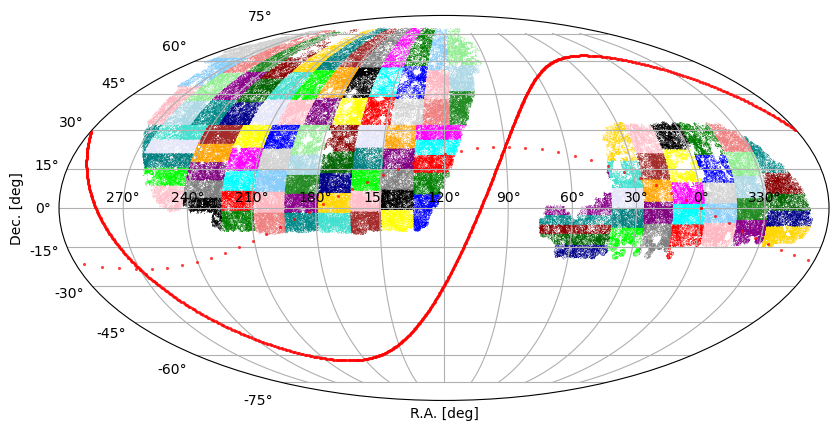

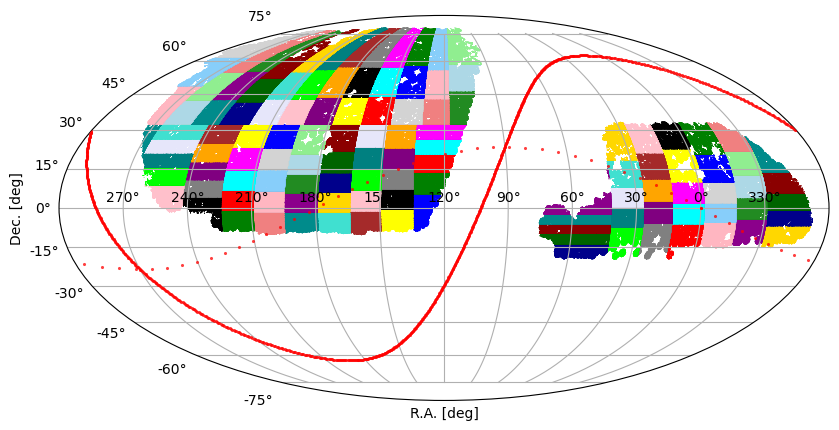

In [5]:
# Visualise the jackknife regions 'Black crosses indicate any unassigned objects'
ca.sky_plot_jack(dat)
ca.sky_plot_jack(ran)

redshift cuts: [0.05 0.1 ]
ireg 0 S
Reading k-correction polynomials from  /global/u2/s/smcole/DESI/NvsS/data//jmext_kcorr_S_rband_z01.dat
Number in volume limited sample: 0  with limits: 0.05 <z< 0.1 N= 469241


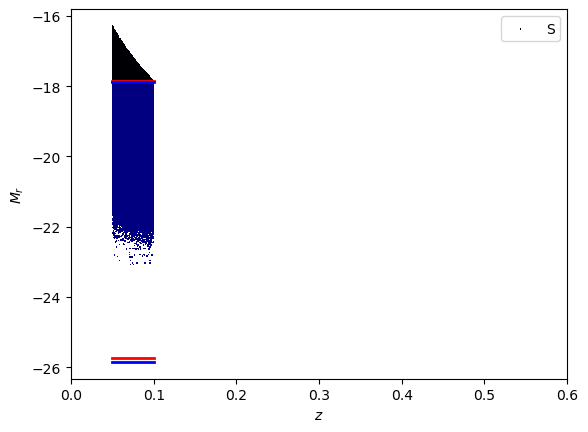

ireg 1 N
Reading k-correction polynomials from  /global/u2/s/smcole/DESI/NvsS/data//jmext_kcorr_N_rband_z01.dat
Number in volume limited sample: 0  with limits: 0.05 <z< 0.1 N= 186059


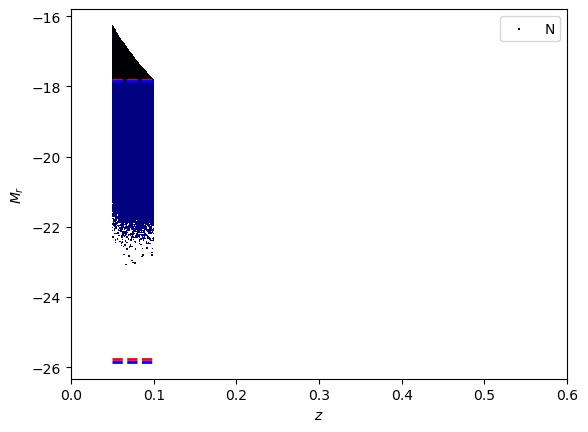

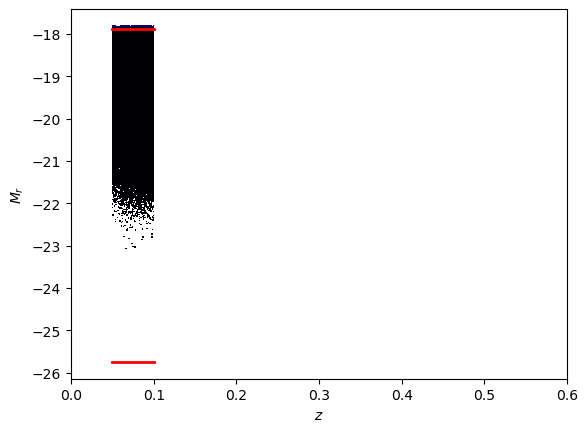

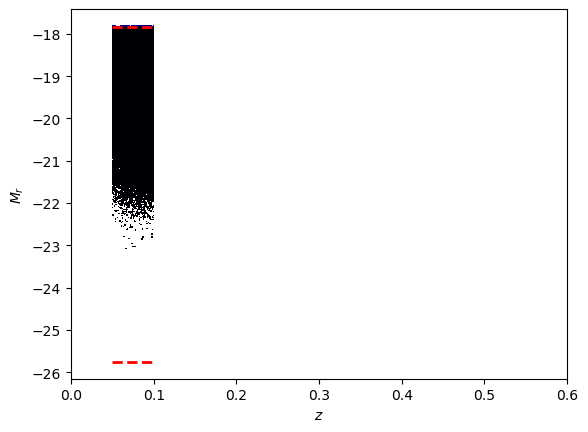

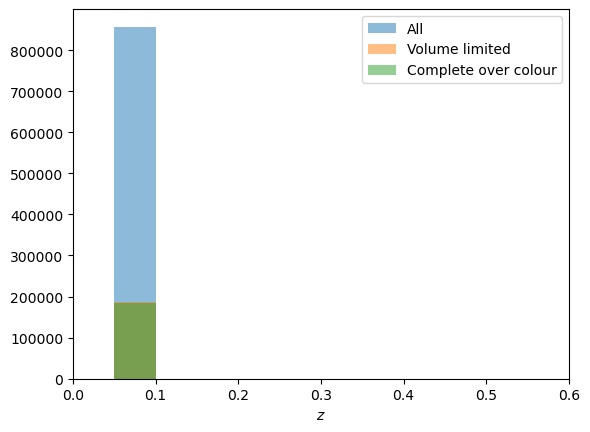

In [8]:
# Define redshift slices and volume limited samples within them

# set up the boundaries of the redshift slices with the lowest limit set by the already imposed Sel['zmin']
zbin_edges= np.array([Sel['zmin'],0.05,0.1,0.2,0.3,0.4,0.5,0.6])
zbin_edges=np.array([0.05,0.1])
print('redshift cuts:',zbin_edges)


# Label according to redshift sample and compute corresponding volumes
# Also returns the bounding absolute magnitudes within which each sample is complete
faint_bound,bright_bound=ca.redshiftslices(dat,zbin_edges,regions,plotfrac=1.0)
# overwrite the original catalogue with one that now contains the redshift slice information
dat.write(catalogue,overwrite=True) 

In [9]:
import matplotlib.pyplot as plt
# premlinary call to set up magnitude bins
print('Preliminary call to set up magnitude bins and set up consistentlty sized arrays to store the results.')
_,_,_,magbins=ca.lumfun_vmax(dat,regions,ratio=False,Vollim=False,plot=False)

# create placeholders for the lF estimates from each redshift slice and each region
log_phi_vlim=np.zeros((zbin_edges.size-1, 2, magbins.size))
log_phi_vlim_hi=np.zeros((zbin_edges.size-1, 2, magbins.size))
log_phi_vlim_low=np.zeros((zbin_edges.size-1, 2, magbins.size))
log_phi_vmax=np.zeros((2, magbins.size))
log_phi_vmax_hi=np.zeros((2, magbins.size))
log_phi_vmax_low=np.zeros((2, magbins.size))

#Loop over regions
ireg = -1
for reg in regions:
    ireg += 1
    print('Making LF estimates for all redshift slices in region ', ireg,'=',reg) 
    #overall standard 1/Vmax LFs
    log_phi_vmax[ireg,:],log_phi_vmax_low[ireg,:],log_phi_vmax_hi[ireg,:],magbins=ca.lumfun_vmax(dat,reg,ratio=False,Vollim=False,plot=False)
 
    # Now estimate LF's from each redshift sample
    #loop over the redshift bins
    for jzbin in range(0,zbin_edges.size-1):  
      mask=(dat['izbin']==jzbin) & dat['invollim'] #select the volume limited subset of this redshift bin
      print('zbin=',jzbin,'sample size:',mask.sum())
      log_phi_vlim[jzbin,ireg,:],log_phi_vlim_low[jzbin,ireg,:],log_phi_vlim_hi[jzbin,ireg,:],magbins=ca.lumfun_vmax(dat[mask],reg,ratio=False,Vollim=True,plot=False)  




print('All LFs computed')

Preliminary call to set up magnitude bins and set up consistentlty sized arrays to store the results.
number of jackknife samples: 80  for region: S  in range: 0 79
number of jackknife samples: 36  for region: N  in range: 80 115
Making LF estimates for all redshift slices in region  0 = S
number of jackknife samples: 80  for region: S  in range: 0 79
zbin= 0 sample size: 655300
number of jackknife samples: 80  for region: S  in range: 0 79
Making LF estimates for all redshift slices in region  1 = N
number of jackknife samples: 36  for region: N  in range: 80 115
zbin= 0 sample size: 655300
number of jackknife samples: 36  for region: N  in range: 80 115
All LFs computed


In [16]:
# Save all the LF Estimates to separate tables in a single fits file along with the limits and bounds that define the sample.
import matplotlib.pyplot as plt

# The edges of the redshift limits  (written in two columns is is doesn't allow single column tables)
SLICES= Table([zbin_edges,zbin_edges],names=('zbin_edges','zbin_edges_copy'))

nzslices=zbin_edges.size-1
print('Number of redshuft slices=',nzslices)
ireg = -1
for reg in regions:
    ireg +=1 
    # print('ireg=',ireg)
    if (reg=='S'): LFVMAXS = Table([magbins, log_phi_vmax[ireg,:], log_phi_vmax_low[ireg,:], log_phi_vmax_hi[ireg,:]], names=('magbins', 'log_phi_vmax', 'log_phi_vmax_low','log_phi_vmax_hi'))
    if (reg=='N'): LFVMAXN = Table([magbins, log_phi_vmax[ireg,:], log_phi_vmax_low[ireg,:], log_phi_vmax_hi[ireg,:]], names=('magbins', 'log_phi_vmax', 'log_phi_vmax_low','log_phi_vmax_hi'))
    if (reg=='S'): BOUNDS_S= Table([faint_bound[ireg,:],bright_bound[ireg,:]],names=('faint','bright'))
    if (reg=='N'): BOUNDS_N= Table([faint_bound[ireg,:],bright_bound[ireg,:]],names=('faint','bright'))

# Build up a list of names and corresponding tables
named_tables = [ ("SLICES",SLICES), ("BOUNDS_S",BOUNDS_S), ("BOUNDS_N",BOUNDS_N), ("LFVMAXS", LFVMAXS), ("LFVMAXN", LFVMAXN) ]
ireg = -1
for reg in regions:
    ireg +=1 
    for jzbin in range(nzslices):
      # print('ireg=',ireg,reg,'jzbin=',jzbin)
      if (reg=='S'): 
          LFVLIMS = Table([magbins, log_phi_vlim[jzbin,ireg,:], log_phi_vlim_low[jzbin,ireg,:], log_phi_vlim_hi[jzbin,ireg,:]], names=('magbins', 'log_phi_vmax', 'log_phi_vmax_low','log_phi_vmax_hi'))
          named_tables.append(("LFVLIMS"+str(jzbin), LFVLIMS))
      if (reg=='N'): 
          LFVLIMN = Table([magbins, log_phi_vlim[jzbin,ireg,:], log_phi_vlim_low[jzbin,ireg,:], log_phi_vlim_hi[jzbin,ireg,:]], names=('magbins', 'log_phi_vmax', 'log_phi_vmax_low','log_phi_vmax_hi'))   
          named_tables.append(("LFVLIMN"+str(jzbin), LFVLIMN))

# Convert them into FITS HDUs and add meta data from original catalogues to the SLICES table    
hdus = [fits.PrimaryHDU()]  # always start with a Primary HDU
for name, tab in named_tables:
    hdu = fits.table_to_hdu(tab)  # convert Table -> BinTableHDU 
    if (name=='SLICES'):
        print("Storing meta data in SLICES HDU header")
        # Add copies of the meta data defining sample selection and cosmology choice from the original catalogue
        SLICES.meta['QEVOL_N']=dat.meta['QEVOL_N']
        SLICES.meta['ZMAX_N']=dat.meta['ZMAX_N']
        SLICES.meta['ZMIN_N']=dat.meta['ZMIN_N']
        SLICES.meta['BRIGHT_N']=dat.meta['BRIGHT_N']
        SLICES.meta['FAINT_N']=dat.meta['FAINT_N']
        SLICES.meta['AREA_N']=dat.meta['AREA_N']
        SLICES.meta['F_RAN_N']=dat.meta['F_RAN_N']
        SLICES.meta['COL_N']=dat.meta['COL_N']
        SLICES.meta['STYLE_N']=dat.meta['STYLE_N']


        SLICES.meta['QEVOL_S']=dat.meta['QEVOL_S']
        SLICES.meta['ZMAX_S']=dat.meta['ZMAX_S']
        SLICES.meta['ZMIN_S']=dat.meta['ZMIN_S']
        SLICES.meta['BRIGHT_S']=dat.meta['BRIGHT_S']
        SLICES.meta['FAINT_S']=dat.meta['FAINT_S']
        SLICES.meta['AREA_S']=dat.meta['AREA_S']
        SLICES.meta['F_RAN_S']=dat.meta['F_RAN_S']
        SLICES.meta['COL_S']=dat.meta['COL_S']
        SLICES.meta['STYLE_S']=dat.meta['STYLE_S']
        #
        # Store the parameters of the cosmology used to make this catalogue
        SLICES.meta['H0']=dat.meta['H0']
        SLICES.meta['TCMB0']=dat.meta['TCMB0']
        SLICES.meta['OM0']=dat.meta['OM0']
        #
        # Store the choices made for some of the processing option flags
        SLICES.meta['PMATCH']=dat.meta['PMATCH']
        # Manually copy metadata to header to make it compliant with FITS header information
        for key, value in SLICES.meta.items():
            hdu.header[key[:8]] = value  # FITS keywords must be ≤8 character

    hdu.name = name               # set EXTNAME  (extension name)
    hdus.append(hdu)              # Append to the list of HDUs (Hieracrhical Data Units)

# Write as separate HDUs in a single FITS file with meta data in the SLICES header
fits.HDUList(hdus).writeto(LF_FILE, overwrite=True)
print("All LFs and meta data saved to ",LF_FILE)


 

Number of redshuft slices= 1
ireg= 0
ireg= 1
ireg= 0 S jzbin= 0
magbins     log_phi_vmax      log_phi_vmax_low    log_phi_vmax_hi  
------- ------------------- ------------------- -------------------
-23.875               -10.0               -10.0               -10.0
-23.625               -10.0               -10.0               -10.0
-23.375               -10.0               -10.0               -10.0
-23.125  -5.155498621395612  -5.406650294345089  -4.997393184015319
-22.875  -5.040566648983994  -5.218263096141853  -4.914827537696556
-22.625   -4.77639688922019  -4.922160235787521 -4.6674551572607115
-22.375   -4.08627959803178  -4.130583902211193 -4.0460795109425325
-22.125  -3.703194445711014   -3.73932540684116  -3.669839882391643
-21.875 -3.3003595276391953 -3.3200106959125417  -3.281559185282994
-21.625  -2.978953508145767  -2.994786620176998 -2.9636773788190602
    ...                 ...                 ...                 ...
-13.875               -10.0               -10.0     